# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data 

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [2]:
import pandas as pd

#url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
#df = pd.read_csv(url)

df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [3]:
df.shape

(17379, 17)

In [4]:
# Check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [6]:
from sklearn.model_selection import train_test_split

target = 'cnt' 

X = df.copy()                 # info used to make prediction - i.e. variables - create new df so the OG remaing intact 
y = df[target].astype(float)  # variable we are trying to predict i.e. target variable y = df['cnt'] dependent 

# remove not needed columns:
X.drop(columns=[
    target,
    'instant',
    'dteday',
    'casual',
    'registered'
], inplace=True)

# cnt - predicting variable
# casual and registered - data leakage, they are parts of cnt which if kept will result in the model learning about thier relationship and not take into consideration the oher variables
# instant - ID no usual explanatory info
# dteday - we have the other time

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, # 20% of df used for testing
    random_state=42 # make the random split reproducible 
)
# X_train - inputs for training 
# y_train - correct answers for training
# X_test - unseen inputs
# y_test - correct answers used for evaluation


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


Which variables are categorical, which are numerical, and what does Python need to do to them before Linear Regression and XGBoost can use them?

In [7]:
from sklearn.compose import ColumnTransformer # Do different things to different columns i.e. this cl one-hot code it while this one do nothing
from sklearn.preprocessing import OneHotEncoder

# df info mentions that the countinous variables are already normalized i.e. numerical_features 

# Categorical variables
categorical_features = [
    'season',
    'yr',
    'mnth',
    'hr',
    'holiday',
    'weekday',
    'workingday',
    'weathersit'
]

# Continuous numerical variables
numerical_features = [
    'temp',
    'atemp',
    'hum',
    'windspeed'
]

# set rule for Preprocessing
# ( no need for StandardScaler() for the linear regression as the numerical variables are already standarlized)
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features), # convert categorical into one-hot encoded column and apply this law to all categorical_features
        ('numerical', 'passthrough', numerical_features) # do not transfom the numerical variables 'passthrough' 
    ]
)

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters. 

In [10]:
# Hyperparameter optimization for XGBoost packages needed:

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV # try these different combinations and tell me which one performs best
from xgboost import XGBRegressor

# XGBoost pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter grid:
param_grid = {
    'model__n_estimators': [200, 400],   # how many trees?
    'model__max_depth': [3, 6],          # depth of the tree
    'model__learning_rate': [0.05, 0.1], # How strongly does each tree contribute?
    'model__subsample': [0.8, 1.0],      # What proportion of observations are used?
    'model__colsample_bytree': [0.8, 1.0]# What proportion of variables are used?
}

# set up grid search 
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,                                   # 5-fold cross-validation i.e. training/valuating 5 times and make the av RMSE
    scoring='neg_root_mean_squared_error',  # neg mens the higher the better whereas we want the opposite for the RMSE
    n_jobs=-1,
    verbose=1
)

# Run hyperparameter optimization
xgb_grid_search.fit(X_train, y_train)

# Results
print("Best XGBoost parameters:")
print(xgb_grid_search.best_params_)
print("Best 5-fold CV RMSE:", -xgb_grid_search.best_score_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 400, 'model__subsample': 0.8}
Best 5-fold CV RMSE: 44.207057853541286


Summary of the best model combination:
400 trees
depth = 6
learning rate = 0.1
80% observations per tree
80% features per tree

and 44.20 is the best sult among the 32 combinations the code tried 

## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [11]:
# import needed packages:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# XGBoost model with the best parameters found by GridSearchCV
best_xgb_model = xgb_grid_search.best_estimator_

# Train XGBoost on the training data
best_xgb_model.fit(X_train, y_train)



# Linear Regression model
reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train Linear Regression on the training data
reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['season','yr','mnth',...,'atemp','hum','windspeed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions
xgb_predictions = best_xgb_model.predict(X_test)
linear_predictions = reg_pipeline.predict(X_test)


# XGBoost performance
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_predictions)


# Linear Regression performance
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)


# Print results
print("XGBoost:")
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R-squared:", xgb_r2)

print("\nLinear Regression:")
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R-squared:", linear_r2)

XGBoost:
MSE: 1743.682786148811
RMSE: 41.757427915866785
R-squared: 0.9449341501482

Linear Regression:
MSE: 10089.3881755191
RMSE: 100.4459465360305
R-squared: 0.6813751108957464


## Visualize the predictions and compare the models
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

Matplotlib is building the font cache; this may take a moment.


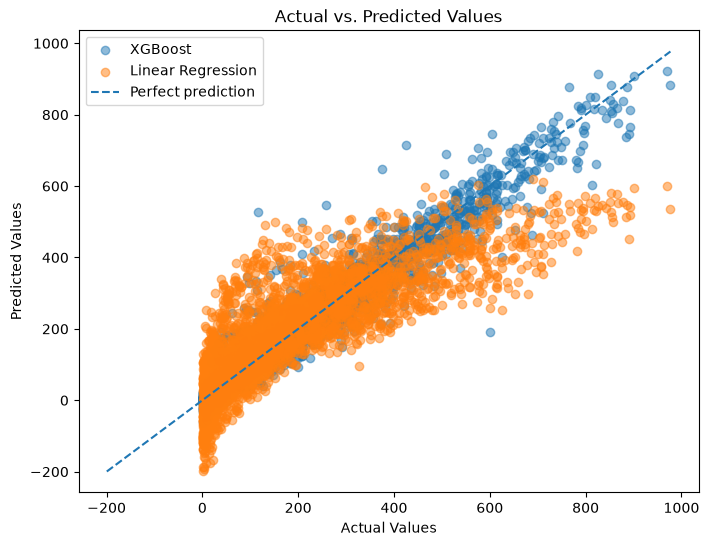

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# create a scatter plot
plt.scatter(y_test, xgb_predictions, alpha=0.5, label='XGBoost')
plt.scatter(y_test, linear_predictions, alpha=0.5, label='Linear Regression')

# Perfect prediction line
min_value = min(y_test.min(), xgb_predictions.min(), linear_predictions.min())
max_value = max(y_test.max(), xgb_predictions.max(), linear_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    label='Perfect prediction'
)

# add labels and title
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()

# show the plot
plt.show()

In [ ]:
# Hyperparameter optimization for XGBoost packages needed:

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV # try these different combinations and tell me which one performs best
from xgboost import XGBRegressor

# XGBoost pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter grid:
param_grid = {
    'model__n_estimators': [200, 400],   # how many trees?
    'model__max_depth': [3, 6],          # depth of the tree
    'model__learning_rate': [0.05, 0.1], # How strongly does each tree contribute?
    'model__subsample': [0.8, 1.0],      # What proportion of observations are used?
    'model__colsample_bytree': [0.8, 1.0]# What proportion of variables are used?
}

# set up grid search 
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,                                   # 5-fold cross-validation i.e. training/valuating 5 times and make the av RMSE
    scoring='neg_root_mean_squared_error',  # neg mens the higher the better whereas we want the opposite for the RMSE
    n_jobs=-1,
    verbose=1
)

# Run hyperparameter optimization
xgb_grid_search.fit(X_train, y_train)

# Results
print("Best XGBoost parameters:")
print(xgb_grid_search.best_params_)
print("Best 5-fold CV RMSE:", -xgb_grid_search.best_score_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 400, 'model__subsample': 0.8}
Best 5-fold CV RMSE: 44.207057853541286
